# Load SVM decoding results (platform paper)

Loads the aggregated `all_sess` SVM decoding outputs (deconvolved **events**) from
Farzaneh's `SVM` folder, for the three platform-paper project codes
(`VisualBehavior`, `VisualBehaviorTask1B`, `VisualBehaviorMultiscope`; excluding `4areasx2d`),
for these decoding types:

- `decode_next_image_from_omissions`
- `decode_changes_from_nochanges`
- `decode_baseline_from_nobaseline`  (candidate **events** equivalent of the old `gray_omit`)
- `gray_omit`  (**only exists as dF/F, Multiscope-only** -- no events / single-plane version)

For each (decoding type x project code) it picks the **latest** standard aggregate file
(excludes `trial_blocks/`, `matched_cells`, `sameNumNeurons`).

In [79]:
import os
import re
import glob
import numpy as np
import pandas as pd

import visual_behavior.data_access.loading as loading

## 1. Platform-paper experiments table

In [80]:
metadata_tables_dir = loading.get_metadata_tables_dir()
platform_experiments = pd.read_csv(
    os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'),
    index_col=0,
)
print(platform_experiments.shape)
platform_experiments.head()

(402, 45)


,behavior_session_id,ophys_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,...,layer,area_layer,date,first_novel,n_relative_to_first_novel,last_familiar,last_familiar_active,second_novel,second_novel_active,experience_exposure
ophys_experiment_id,,,,,,,,,,,,,,,,,,,,,
795073741,794968300,794918442,791352433,412036,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,['Vip-IRES-Cre'],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,...,upper,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3
795953296,795742990,795625712,791352433,412036,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,['Vip-IRES-Cre'],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,...,upper,VISp_upper,20181214,True,0.0,False,False,False,False,Novel 0
796308505,796251270,796236521,791352433,412036,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,['Vip-IRES-Cre'],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,...,upper,VISp_upper,20181216,False,2.0,False,False,False,True,Novel 2
807752719,807356557,807208045,803517529,425493,GCaMP6f,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-G...,"['Slc17a7-IRES2-Cre', 'Camk2a-tTA']",Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),M,...,lower,VISp_lower,20190111,False,-1.0,True,True,False,False,Familiar > 3
808619543,808324301,808107961,803517529,425493,GCaMP6f,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-G...,"['Slc17a7-IRES2-Cre', 'Camk2a-tTA']",Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),M,...,lower,VISp_lower,20190114,True,0.0,False,False,False,False,Novel 0


## 2. Project codes

The three project codes we want come from the experiments table (we drop `4areasx2d`).

In [81]:
project_codes = ['VisualBehavior', 'VisualBehaviorTask1B', 'VisualBehaviorMultiscope']

if 'project_code' in platform_experiments.columns:
    print(platform_experiments['project_code'].value_counts())
    exp_ids_by_project = {
        pc: set(platform_experiments.index[platform_experiments['project_code'] == pc])
        for pc in project_codes
    }
else:
    print('NOTE: no "project_code" column; available columns:', list(platform_experiments.columns))
    exp_ids_by_project = {pc: set() for pc in project_codes}

VisualBehaviorMultiscope    261
VisualBehavior               75
VisualBehaviorTask1B         66
Name: project_code, dtype: int64


## 3. SVM directory and file-finding helpers

In [82]:
# Location of the SVM h5 outputs.
platform_cache_dir = loading.get_platform_analysis_cache_dir()
dir_svm = os.path.join(platform_cache_dir, 'visual_behavior_ophys_decoding')

_PC_RE = re.compile(r'_(VisualBehaviorMultiscope|VisualBehaviorTask1B|VisualBehavior)_\d{8}_\d{6}\.h5$')
_TS_RE = re.compile(r'_(\d{8})_(\d{6})\.h5$')

def _project_code(fname):
    m = _PC_RE.search(fname)
    return m.group(1) if m else None

def _timestamp(fname):
    m = _TS_RE.search(fname)
    return m.group(1) + m.group(2) if m else ''

In [83]:
def find_all_sess_events_file(decoding_type, project_code, dir_svm=dir_svm):
    """Latest standard all_sess events aggregate for a (decoding_type, project_code)."""
    cands = glob.glob(os.path.join(dir_svm, f'all_sess_events_svm_{decoding_type}_*.h5'))
    keep = []
    for f in cands:
        b = os.path.basename(f)
        if 'matched_cells' in b or 'sameNumNeurons' in b:
            continue
        if _project_code(b) != project_code:
            continue
        keep.append(f)
    keep.sort(key=lambda f: _timestamp(os.path.basename(f)))
    return keep[-1] if keep else None

def find_gray_omit_aggregate(dir_svm=dir_svm):
    """gray_omit only exists as dF/F, Multiscope-only (no events, no project code in name)."""
    cands = glob.glob(os.path.join(dir_svm, 'all_sess_svm_gray_omit_*.h5'))
    cands = [f for f in cands
             if 'sameNumNeurons' not in os.path.basename(f)
             and 'spontFrs' not in os.path.basename(f)]
    cands.sort(key=lambda f: _timestamp(os.path.basename(f)))
    return cands[-1] if cands else None

def load_svm_h5(filepath, key='all_sess'):
    """Load an all_sess SVM h5 as a DataFrame."""
    return pd.read_hdf(filepath, key=key)

## 4. Other keys in the h5 (analysis parameters)

Each `all_sess` file stores more than one key. Besides `all_sess`, there is usually a parameters
table (likely `input_vars`) describing how the SVM was run -- e.g. frames used, samples before/after
the aligned event, number of CV shuffles, regularization. Listing the keys and loading the extra
one(s) can give us the *actual* time-axis / window parameters instead of our hardcoded guesses.

In [84]:
decoding_type = 'decode_changes_from_nochanges'
project_code  = 'VisualBehaviorMultiscope'
fp = find_all_sess_events_file(decoding_type, project_code)

with pd.HDFStore(fp, mode='r') as store:
    h5_keys = [k.strip('/') for k in store.keys()]
print(os.path.basename(fp))
print('keys:', h5_keys)

extras = {}
for k in h5_keys:
    if k == 'all_sess':
        continue
    obj = pd.read_hdf(fp, key=k)
    extras[k] = obj
    print(f'\n=== key: {k!r}   type={type(obj).__name__}   shape={getattr(obj, "shape", None)} ===')
    if isinstance(obj, pd.DataFrame):
        print('columns:', list(obj.columns))
    try:
        print(obj.head())
    except AttributeError:
        print(obj)

all_sess_events_svm_decode_changes_from_nochanges_equalTrs_frames-5to7_VisualBehaviorMultiscope_20220114_110349.h5
keys: ['all_sess', 'input_vars']

=== key: 'input_vars'   type=DataFrame   shape=(1, 7) ===
columns: ['frames_svm', 'time_win', 'use_events', 'trial_type', 'to_decode', 'same_num_neuron_all_planes', 'project_codes']
                                     frames_svm  time_win use_events  \
0  [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7]  [0, 0.4]       True   

             trial_type to_decode same_num_neuron_all_planes  \
0  changes_vs_nochanges   current                          0   

                project_codes  
0  [VisualBehaviorMultiscope]  


## 5. Load the aggregate events files

In [85]:
decoding_types = [
    'decode_next_image_from_omissions',
    'decode_changes_from_nochanges',
    'decode_baseline_from_nobaseline',
]

results = {}
input_vars_all = {}
summary = []

for decoding_type in decoding_types:
    results[decoding_type] = {}
    input_vars_all[decoding_type] = {}
    for project_code in project_codes:
        fp = find_all_sess_events_file(decoding_type, project_code)
        if fp is None:
            summary.append({'decoding_type': decoding_type, 'project_code': project_code, 'file': None})
            print(f'[missing] {decoding_type} / {project_code}')
            continue
        df = load_svm_h5(fp)
        results[decoding_type][project_code] = df
        try:
            input_vars_all[decoding_type][project_code] = pd.read_hdf(fp, key='input_vars')
        except KeyError:
            input_vars_all[decoding_type][project_code] = None
        summary.append({
            'decoding_type': decoding_type, 'project_code': project_code,
            'file': os.path.basename(fp),
            'shape': df.shape,
            'n_columns': df.shape[1],
        })
        print(f'[ok] {decoding_type} / {project_code}: {os.path.basename(fp)}  {df.shape}')

[ok] decode_next_image_from_omissions / VisualBehavior: all_sess_events_svm_decode_next_image_from_omissions_frames-15to22_VisualBehavior_20220113_203717.h5  (189, 27)
[ok] decode_next_image_from_omissions / VisualBehaviorTask1B: all_sess_events_svm_decode_next_image_from_omissions_frames-15to22_VisualBehaviorTask1B_20220113_203449.h5  (193, 27)
[ok] decode_next_image_from_omissions / VisualBehaviorMultiscope: all_sess_events_svm_decode_next_image_from_omissions_frames-5to7_VisualBehaviorMultiscope_20220114_105103.h5  (1272, 27)
[ok] decode_changes_from_nochanges / VisualBehavior: all_sess_events_svm_decode_changes_from_nochanges_equalTrs_frames-15to22_VisualBehavior_20220113_202511.h5  (189, 27)
[ok] decode_changes_from_nochanges / VisualBehaviorTask1B: all_sess_events_svm_decode_changes_from_nochanges_equalTrs_frames-15to22_VisualBehaviorTask1B_20220113_202313.h5  (193, 27)
[ok] decode_changes_from_nochanges / VisualBehaviorMultiscope: all_sess_events_svm_decode_changes_from_nochange

In [86]:
# gray_omit: dF/F, Multiscope-only aggregate (predates the events pipeline & project codes)
results['gray_omit'] = {}
fp = find_gray_omit_aggregate()
if fp is not None:
    try:
        df = load_svm_h5(fp)
        results['gray_omit']['VisualBehaviorMultiscope (dF/F)'] = df
        summary.append({
            'decoding_type': 'gray_omit',
            'project_code': 'VisualBehaviorMultiscope (dF/F)',
            'file': os.path.basename(fp),
            'shape': df.shape,
            'n_columns': df.shape[1],
        })
        print(f'[ok] gray_omit (dF/F, Multiscope): {os.path.basename(fp)}  {df.shape}')
    except Exception as e:
        with pd.HDFStore(fp, mode='r') as store:
            avail = [k.strip('/') for k in store.keys()]
        print(f'[skip] gray_omit not readable with key="all_sess" ({e}); available keys: {avail}')
else:
    print('[missing] gray_omit aggregate')

[missing] gray_omit aggregate


In [87]:
summary_df = pd.DataFrame(summary)
summary_df

,decoding_type,project_code,file,shape,n_columns
0,decode_next_image_from_omissions,VisualBehavior,all_sess_events_svm_decode_next_image_from_omi...,"(189, 27)",27
1,decode_next_image_from_omissions,VisualBehaviorTask1B,all_sess_events_svm_decode_next_image_from_omi...,"(193, 27)",27
2,decode_next_image_from_omissions,VisualBehaviorMultiscope,all_sess_events_svm_decode_next_image_from_omi...,"(1272, 27)",27
3,decode_changes_from_nochanges,VisualBehavior,all_sess_events_svm_decode_changes_from_nochan...,"(189, 27)",27
4,decode_changes_from_nochanges,VisualBehaviorTask1B,all_sess_events_svm_decode_changes_from_nochan...,"(193, 27)",27
5,decode_changes_from_nochanges,VisualBehaviorMultiscope,all_sess_events_svm_decode_changes_from_nochan...,"(1272, 27)",27
6,decode_baseline_from_nobaseline,VisualBehavior,all_sess_events_svm_decode_baseline_from_nobas...,"(189, 27)",27
7,decode_baseline_from_nobaseline,VisualBehaviorTask1B,all_sess_events_svm_decode_baseline_from_nobas...,"(193, 27)",27
8,decode_baseline_from_nobaseline,VisualBehaviorMultiscope,all_sess_events_svm_decode_baseline_from_nobas...,"(1272, 27)",27


## 6. Inspect one dataframe -- columns and which are timeseries

Pick one `(decoding_type, project_code)`, load it, and see which columns hold per-timepoint
arrays (the `av_`/`sd_` decoding traces).

In [88]:
decoding_type = 'decode_changes_from_nochanges'   # the "Time from change" figure
project_code = 'VisualBehaviorMultiscope'

df = results[decoding_type][project_code]
print(decoding_type, '/', project_code, '->', df.shape)

def _is_array(x):
    return isinstance(x, (np.ndarray, list)) and np.ndim(x) >= 1

array_cols, scalar_cols = [], []
for col in df.columns:
    s = df[col].dropna()
    val = s.iloc[0] if len(s) else None
    (array_cols if _is_array(val) else scalar_cols).append(col)

print('\nScalar columns:'); print(scalar_cols)
print('\nArray (timeseries) columns:'); print(array_cols)
print('\nav_/sd_ columns:', [c for c in df.columns if c.startswith(('av_', 'sd_'))])
for c in array_cols[:10]:
    print(f'  {c}: shape={np.shape(df[c].dropna().iloc[0])}')
df.head()

decode_changes_from_nochanges / VisualBehaviorMultiscope -> (1272, 27)

Scalar columns:
['session_id', 'experiment_id', 'mouse_id', 'date', 'cre', 'stage', 'experience_level', 'area', 'depth', 'n_trials', 'n_neurons', 'frame_dur']

Array (timeseries) columns:
['cell_specimen_id', 'meanX_allFrs', 'stdX_allFrs', 'av_train_data', 'av_test_data', 'av_test_shfl', 'av_test_chance', 'sd_train_data', 'sd_test_data', 'sd_test_shfl', 'sd_test_chance', 'peak_amp_trainTestShflChance', 'bl_pre0', 'av_w_data', 'av_b_data']

av_/sd_ columns: ['av_train_data', 'av_test_data', 'av_test_shfl', 'av_test_chance', 'sd_train_data', 'sd_test_data', 'sd_test_shfl', 'sd_test_chance', 'av_w_data', 'av_b_data']
  cell_specimen_id: shape=(26,)
  meanX_allFrs: shape=(13, 26)
  stdX_allFrs: shape=(13, 26)
  av_train_data: shape=(13,)
  av_test_data: shape=(13,)
  av_test_shfl: shape=(13,)
  av_test_chance: shape=(13,)
  sd_train_data: shape=(13,)
  sd_test_data: shape=(13,)
  sd_test_shfl: shape=(13,)


,session_id,experiment_id,mouse_id,date,cre,stage,experience_level,area,depth,n_trials,...,av_test_shfl,av_test_chance,sd_train_data,sd_test_data,sd_test_shfl,sd_test_chance,peak_amp_trainTestShflChance,bl_pre0,av_w_data,av_b_data
0,846871218,847267630,438912,2019-04-05,Vip-IRES-Cre,OPHYS_1_images_A,Familiar,VISl,75,404,...,"[50.53658536585367, 50.78048780487803, 48.9024...","[49.85365853658536, 50.146341463414636, 49.829...","[0.14406724850612682, 0.08935900313727879, 0.1...","[0.4767029337973676, 0.39605430497920896, 0.45...","[0.41126319821186336, 0.4751530014394508, 0.42...","[0.5306097420834012, 0.48980079477312094, 0.44...","[62.329192546583826, 60.19512195121952, 50.109...","[53.496894409937894, 49.14634146341464, 49.253...","[[0.016239335659839222, 0.00041539877166446414...","[-0.0003198972954183596, -1.527760956460089e-0..."
1,846871218,847267626,438912,2019-04-05,Vip-IRES-Cre,OPHYS_1_images_A,Familiar,VISl,150,404,...,"[49.95121951219513, 50.17073170731705, 49.4878...","[49.80487804878048, 50.41463414634147, 50.3170...","[0.13055008213645625, 0.12981515051602807, 0.0...","[0.35885998356584453, 0.32797396916482946, 0.3...","[0.4051424349823634, 0.39930039950172463, 0.43...","[0.4942982454982792, 0.4492177085476642, 0.438...","[60.85248447204967, 58.56707317073171, 49.9451...","[52.80621118012424, 48.258536585365846, 49.673...","[[0.1670370398172757, -0.0046517760790080335, ...","[-0.013470206751318277, 0.0021299062690224415,..."
2,846871218,847267624,438912,2019-04-05,Vip-IRES-Cre,OPHYS_1_images_A,Familiar,VISl,225,404,...,"[50.21951219512194, 50.14634146341462, 50.6341...","[50.60975609756097, 50.09756097560974, 49.4634...","[0.11187368253572083, 0.12044245424491168, 0.0...","[0.4297253664159755, 0.4043781809963455, 0.312...","[0.4750653544695212, 0.44660128383401365, 0.40...","[0.45006444115234007, 0.44952218667349386, 0.3...","[59.53260869565216, 57.536585365853654, 49.975...","[53.599999999999994, 50.829268292682926, 49.68...","[[-0.042718913880283364, 0.003883535688223829,...","[-0.015675506776513866, 0.0007622859866123425,..."
3,846871218,847267628,438912,2019-04-05,Vip-IRES-Cre,OPHYS_1_images_A,Familiar,VISl,300,404,...,"[49.63414634146341, 49.87804878048781, 49.5609...","[49.82926829268291, 49.92682926829271, 50.0487...","[0.06062824517720469, 0.04190590756132412, 0.0...","[0.2019830303684233, 0.1800588178077244, 0.172...","[0.2609870068174719, 0.291154546007642, 0.2091...","[0.24147573262495323, 0.25208234493081416, 0.2...","[52.39751552795032, 51.554878048780495, 49.981...","[50.74285714285716, 48.858536585365854, 49.531...","[[-8.213153354306686e-08, 0.0, 0.0147979708183...","[-7.279177167316927e-23, -7.279176934570291e-2..."
4,846871218,847267622,438912,2019-04-05,Vip-IRES-Cre,OPHYS_1_images_A,Familiar,VISp,75,404,...,"[49.463414634146346, 50.39024390243902, 49.585...","[50.09756097560976, 49.90243902439021, 49.9756...","[0.11877491494958041, 0.08985411836037316, 0.0...","[0.44462551668705735, 0.3672493702384141, 0.33...","[0.4744012162503108, 0.40437818099634576, 0.33...","[0.48023393070200865, 0.4468676093892212, 0.36...","[61.14285714285712, 58.64634146341464, 50.3658...","[53.82111801242236, 50.73170731707317, 49.5121...","[[-0.08446046578247964, -8.962308568333153e-08...","[-0.02165651646574891, -7.279170180747178e-23,..."


## 7. Config + labels (experience level and cell type)

`experience_level` comes from the experiments table; we merge it onto each row by experiment id.
**All column-name / window / color / label assumptions live in this cell.**

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf

# ---- column names in the all_sess dataframe ----
VALUE_COL  = 'av_test_data'   # mean test-set accuracy over time (per session/experiment)
SD_COL     = 'sd_test_data'   # its std
SHFL_COL   = 'av_test_shfl'   # shuffled (chance) accuracy over time
EXP_ID_COL = 'experiment_id'  # ophys_experiment_id in all_sess
CRE_COL    = 'cre'            # cre line in all_sess

# ---- canonical labels (match visual_behavior.visualization.utils so house plotters/stats work) ----
EXP_ORDER       = utils.get_experience_levels()                 # ['Familiar', 'Novel', 'Novel +']
EXP_COLORS      = dict(zip(EXP_ORDER, utils.get_experience_level_colors()))
EXP_MAP         = {'Familiar': 'Familiar', 'Novel 1': 'Novel', 'Novel >1': 'Novel +'}
CRE_TO_CELLTYPE = {'Slc17a7-IRES2-Cre': 'Excitatory',
                   'Sst-IRES-Cre':      'Sst Inhibitory',
                   'Vip-IRES-Cre':      'Vip Inhibitory'}
CELLTYPE_ORDER  = utils.get_cell_types()                        # ['Excitatory', 'Sst Inhibitory', 'Vip Inhibitory']

# ---- per-decoding-type parameters; Methods text (Main Text revised v6) is ground truth ----
# Summary averaging window after event onset:
#   400 ms for image-change and post-omission image-identity decoding,
#   750 ms for omission-occurrence decoding.
SUMMARY_WINDOW_SEC = {
    'decode_changes_from_nochanges':    (0.0, 0.40),
    'decode_next_image_from_omissions': (0.0, 0.40),
    'decode_baseline_from_nobaseline':  (0.0, 0.75),
}
# Chance level: 2-class decoders = 50%; post-omission image identity = 8 classes = 12.5%.
CHANCE_PCT = {
    'decode_changes_from_nochanges':    50.0,
    'decode_next_image_from_omissions': 100.0 / 8,
    'decode_baseline_from_nobaseline':  50.0,
}
# x-axis label: what t=0 is aligned to, per decoding type
EVENT_LABEL = {
    'decode_changes_from_nochanges':    'change',
    'decode_next_image_from_omissions': 'omission',
    'decode_baseline_from_nobaseline':  'omission',
}

# timepoints (sec) to blank out (NaN -> gap) before plotting/averaging, per decoding type.
# baseline_from_nobaseline: the frames used to define the baseline collapse to ~chance
# (the dip just before 0). NOTE: this blanking is applied here but is not yet described in
# the Methods -- tracked in Revision_ToDo_Notes.docx.
EXCLUDE_TIME_SEC = {
    'decode_baseline_from_nobaseline': (-0.08, 0.0),
}

exp_level_by_eid = platform_experiments['experience_level']  # index = ophys_experiment_id
mouse_by_eid     = platform_experiments['mouse_id'] if 'mouse_id' in platform_experiments.columns else None

def add_labels(df):
    """Attach canonical experience_level, mouse_id, and cell_type columns by experiment id / cre."""
    df = df.copy()
    if EXP_ID_COL in df.columns:
        raw_exp = df[EXP_ID_COL].map(exp_level_by_eid)
        df['experience_level'] = raw_exp.map(EXP_MAP).fillna(raw_exp)   # Familiar / Novel / Novel +
        if mouse_by_eid is not None:
            df['mouse_id'] = df[EXP_ID_COL].map(mouse_by_eid)
    if CRE_COL in df.columns:
        df['cell_type'] = df[CRE_COL].map(CRE_TO_CELLTYPE).fillna(df[CRE_COL])
    return df

df = add_labels(df)
print(df['experience_level'].value_counts(dropna=False))
print(df['cell_type'].value_counts(dropna=False))
if 'mouse_id' in df.columns:
    print('n mice:', df['mouse_id'].nunique())

NaN         1011
Familiar      87
Novel         87
Novel +       87
Name: experience_level, dtype: int64
NaN               422
Excitatory        331
Vip Inhibitory    326
Sst Inhibitory    193
Name: cell_type, dtype: int64
n mice: 19


## 8. Time axis + stacking helpers

In [90]:
TIME_COL = next((c for c in ['time_trace', 'time_trace_sec', 'times', 'time'] if c in df.columns), None)

def frame_duration(df, project_code):
    if 'frame_dur' in df.columns:
        return float(np.nanmedian(df['frame_dur'].astype(float)))
    return 0.093 if 'Multiscope' in str(project_code) else 0.032

def get_time(df, project_code, frames_svm=None):
    # exact axis: frame offsets (frames_svm, from input_vars) x per-frame duration
    if frames_svm is not None:
        return np.asarray(frames_svm, float) * frame_duration(df, project_code)
    # fallback if input_vars unavailable
    n = int(np.shape(df[VALUE_COL].dropna().iloc[0])[0])
    samps_before = 5 if 'Multiscope' in str(project_code) else 15
    return (np.arange(n) - samps_before) * frame_duration(df, project_code)

def stack(d, col):
    arrs = [np.asarray(a, float) for a in d[col].dropna() if np.ndim(a) == 1]
    if arrs:
        L = pd.Series([a.shape[0] for a in arrs]).mode().iloc[0]  # modal frame count
        arrs = [a for a in arrs if a.shape[0] == L]               # drop off-length sessions
    return np.vstack(arrs) if arrs else np.empty((0, 0))

def to_pct(a):
    a = np.asarray(a, float)
    return a * 100 if np.nanmax(a) <= 1.5 else a   # handle fraction vs percent storage

def stars(p):
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 0.05 else 'n.s.'

def get_time_array(t_start, t_end, sampling_rate=None, step_size=None, include_endpoint=True):
    # from brain_observatory_utilities (BOU) general_utilities.get_time_array
    if not step_size:
        step_size = 1.0 / sampling_rate
    n_steps = (t_end - t_start) / step_size
    if n_steps != int(n_steps):
        n_steps = int(n_steps)
        t_end = t_start + n_steps * step_size
        include_endpoint = True
    if include_endpoint:
        n_steps += 1
    return np.linspace(t_start, t_end, int(n_steps), endpoint=include_endpoint)

## 9. Plotting functions: time-resolved trace + window-average point-plot

Two house-style outputs per decoding type, matching the paper's panels: a time-resolved decoding-accuracy trace (mean +/- SEM, experience-level colors, gray dotted chance line; chance = 50% for 2-class decoders, 12.5% for the 8-class post-omission image-identity decoder) and a window-averaged point-plot (95% CI) with mixed-linear-model stats (random intercept for `mouse_id`, auto-falling back to ANOVA/Tukey) across experience levels. The averaging window, chance level, x-axis label, and any blanked baseline frames are set per `decoding_type` in Section 7.

In [91]:
# Two house-style outputs per decoding type, matching the paper's figure structure
# (cell types stacked as rows, experience levels as colors):
#   1. time-resolved decoding accuracy (mean +/- SEM per timepoint)
#   2. window-averaged accuracy point-plot with 95% CI (+ gray shuffle) and paper-consistent stats
#
# Stats: ppf.add_stats_to_plot -> compute_stats uses a mixed linear model with a random
# intercept for mouse_id (sessions nested in mice), auto-falling back to ANOVA/Tukey when a
# mouse has no repeated sessions within an experience level -- same path as the rest of the paper.

# y-axis label per decoding type (also encodes which decoder this is, replacing the suptitle)
YLABEL = {
    'decode_changes_from_nochanges':    '% classification accuracy (change vs. pre-change)',
    'decode_baseline_from_nobaseline':  '% classification accuracy (omission vs. baseline)',
    'decode_next_image_from_omissions': '% classification accuracy (image identity)',
}
# stimulus overlay (utils.plot_flashes_on_trace): change flash vs. omission dashed line
FLASH_KIND = {
    'decode_changes_from_nochanges':    dict(change=True,  omitted=False),
    'decode_baseline_from_nobaseline':  dict(change=False, omitted=True),
    'decode_next_image_from_omissions': dict(change=False, omitted=True),
}

def _excl_mask(t, decoding_type):
    excl = EXCLUDE_TIME_SEC.get(decoding_type)
    return (t >= excl[0]) & (t < excl[1]) if excl else np.zeros(len(t), dtype=bool)

def _time_axis(df, project_code, decoding_type, time_override=None):
    if time_override is not None:
        return np.asarray(time_override, float)
    iv = input_vars_all.get(decoding_type, {}).get(project_code)
    frames_svm = iv['frames_svm'].iloc[0] if iv is not None and 'frames_svm' in iv.columns else None
    return get_time(df, project_code, frames_svm=frames_svm)

def build_window_metric_df(df, project_code, decoding_type, time_override=None):
    """One row per session: windowed-mean test accuracy (%) and shuffle (%) + labels."""
    df = add_labels(df)
    t = _time_axis(df, project_code, decoding_type, time_override)
    w0, w1 = SUMMARY_WINDOW_SEC[decoding_type]
    win = (t >= w0) & (t <= w1) & ~_excl_mask(t, decoding_type)
    rows = []
    for _, r in df.iterrows():
        a = np.asarray(r[VALUE_COL], float)
        if a.ndim != 1 or a.shape[0] != t.shape[0]:
            continue   # drop off-length sessions
        sh = np.asarray(r[SHFL_COL], float) if SHFL_COL in df.columns else None
        rows.append({
            'experiment_id':     r.get('experiment_id'),
            'mouse_id':          r.get('mouse_id'),
            'cell_type':         r.get('cell_type'),
            'experience_level':  r.get('experience_level'),
            'decoding_accuracy': np.nanmean(to_pct(a)[win]),
            'shuffle_accuracy':  (np.nanmean(to_pct(sh)[win]) if sh is not None and sh.shape == a.shape else np.nan),
        })
    out = pd.DataFrame(rows)
    if len(out):
        out = out[out['experience_level'].isin(EXP_ORDER) & out['cell_type'].isin(CELLTYPE_ORDER)].copy()
    return out

def plot_decoding_timecourse(df, project_code, decoding_type, axes=None, time_override=None, ylims=None):
    """Time-resolved decoding accuracy, one row per cell type (horiz=False).
    Stimulus context via utils.plot_flashes_on_trace; SEM computed per-timepoint."""
    df = add_labels(df)
    t = _time_axis(df, project_code, decoding_type, time_override)
    excl_mask = _excl_mask(t, decoding_type)
    chance = CHANCE_PCT[decoding_type]
    cell_types = [c for c in CELLTYPE_ORDER if c in df['cell_type'].unique()]
    if axes is None:
        fig, axes = plt.subplots(len(cell_types), 1, figsize=(3.0, 2.2 * len(cell_types)), sharex=True)
    axes = np.atleast_1d(axes)
    mid = len(cell_types) // 2
    for k, (ax, ct) in enumerate(zip(axes, cell_types)):
        d_ct = df[df['cell_type'] == ct]
        for exp in EXP_ORDER:
            M = stack(d_ct[d_ct['experience_level'] == exp], VALUE_COL)
            if M.size == 0 or M.shape[1] != t.shape[0]:
                continue
            Mp = to_pct(M)
            Mp[:, excl_mask] = np.nan                       # gap at blanked frames
            mu = np.nanmean(Mp, 0)
            n = np.sum(~np.isnan(Mp), 0)
            sem = np.nanstd(Mp, 0) / np.sqrt(np.where(n > 0, n, np.nan))
            ax.plot(t, mu, color=EXP_COLORS[exp], lw=1.5, label=exp)
            ax.fill_between(t, mu - sem, mu + sem, color=EXP_COLORS[exp], alpha=0.3, lw=0)
        utils.plot_flashes_on_trace(ax, t, alpha=0.15, **FLASH_KIND[decoding_type])  # change flash / omission line
        ax.axhline(chance, color='gray', lw=0.8, ls=':')
        ax.set_xlim(t[0], t[-1])   # clip to the data window so flashes outside it aren't drawn
        ax.set_xticks(np.arange(np.ceil(t[0] / 0.25) * 0.25, t[-1] + 1e-9, 0.25))
        ax.set_title(ct)
        ax.set_ylabel(YLABEL[decoding_type] if k == mid else '')
        if ylims is not None:
            ax.set_ylim(ylims)
        sns.despine(ax=ax)
    axes[-1].set_xlabel('Time from {} (s)'.format(EVENT_LABEL[decoding_type]))  # bottom row only
    axes[0].legend(frameon=False, fontsize=8)
    return axes

def plot_decoding_window_summary(metric_df, decoding_type, axes=None, ylims=None):
    """Window-averaged accuracy point-plot (95% CI) + gray shuffle, one row per cell type
    (horiz=False), with MLM / ANOVA-fallback stats. Mirrors
    ppf.plot_metric_distribution_by_experience(plot_type='pointplot')."""
    cell_types = [c for c in CELLTYPE_ORDER if c in metric_df['cell_type'].unique()]
    if axes is None:
        fig, axes = plt.subplots(len(cell_types), 1, figsize=(2.2, 2.2 * len(cell_types)), sharex=True)
    axes = np.atleast_1d(axes)
    chance = CHANCE_PCT[decoding_type]
    palette = [EXP_COLORS[e] for e in EXP_ORDER]
    mid = len(cell_types) // 2
    for k, (ax, ct) in enumerate(zip(axes, cell_types)):
        ct_data = metric_df[metric_df['cell_type'] == ct]
        # shuffle (gray) first so colored data sits on top
        if 'shuffle_accuracy' in ct_data and ct_data['shuffle_accuracy'].notna().any():
            sns.pointplot(data=ct_data, x='experience_level', y='shuffle_accuracy', order=EXP_ORDER,
                          color='0.6', estimator=np.mean, markers='.', markersize=4, linestyle='none',
                          err_kws={'linewidth': 1.5}, errorbar=('ci', 95), n_boot=1000, ax=ax)
        sns.pointplot(data=ct_data, x='experience_level', y='decoding_accuracy', order=EXP_ORDER,
                      hue='experience_level', hue_order=EXP_ORDER, palette=palette,
                      estimator=np.mean, markers='.', markersize=5, err_kws={'linewidth': 2},
                      errorbar=('ci', 95), n_boot=1000, ax=ax)
        if ax.get_legend() is not None:
            ax.get_legend().remove()
        ax.axhline(chance, color='gray', lw=0.8, ls=':')
        if ylims is not None:
            ax.set_ylim(ylims)
        # paper-consistent stats on the real data: MLM (random intercept = mouse_id), ANOVA/Tukey fallback
        ax, _ = ppf.add_stats_to_plot(ct_data, 'decoding_accuracy', ax,
                                      group_column='mouse_id',
                                      event_type=EVENT_LABEL[decoding_type], cell_type=ct)
        ax.set_title(ct)
        ax.set_xlabel('')
        ax.set_ylabel(YLABEL[decoding_type] if k == mid else '')
        sns.despine(ax=ax)
    # abbreviated, experience-colored x labels on the bottom row only
    axes[-1].set_xticks(range(len(EXP_ORDER)))
    axes[-1].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)
    utils.color_xaxis_labels_by_experience(axes[-1])
    return axes

def show_decoding_figures(df, project_code, decoding_type, time_override=None,
                          ts_ylims=None, pt_ylims=None):
    """Time-resolved figure + window-average figure for one (df, decoding_type)."""
    plot_decoding_timecourse(df, project_code, decoding_type, time_override=time_override, ylims=ts_ylims)
    plt.tight_layout(); plt.show()
    mdf = build_window_metric_df(df, project_code, decoding_type, time_override=time_override)
    plot_decoding_window_summary(mdf, decoding_type, ylims=pt_ylims)
    plt.tight_layout(); plt.show()
    return mdf

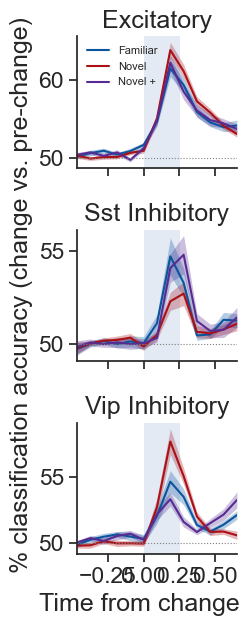

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/909537040.py:26: RuntimeWarning: All-NaN slice encountered
  return a * 100 if np.nanmax(a) <= 1.5 else a   # handle fraction vs percent storage
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:51: RuntimeWarning: Mean of empty slice
  'decoding_accuracy': np.nanmean(to_pct(a)[win]),
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:52: RuntimeWarning: Mean of empty slice
  'shuffle_accuracy':  (np.nanmean(to_pct(sh)[win]) if sh is not None and sh.shape == a.shape else np.nan),


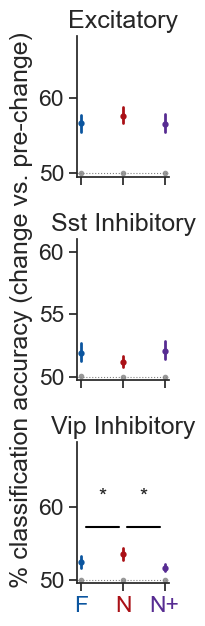

In [92]:
decoding_type = 'decode_changes_from_nochanges'
project_code = 'VisualBehaviorMultiscope'

_ = show_decoding_figures(results[decoding_type][project_code], project_code, decoding_type)

## 10. decode_changes_from_nochanges -- each project code separately

Same figure as Section 10 but one figure per project code (not aggregated), so the sampling-rate
difference is visible: single-plane (VisualBehavior, VisualBehaviorTask1B) ~30 Hz vs Multiscope ~10.7 Hz.

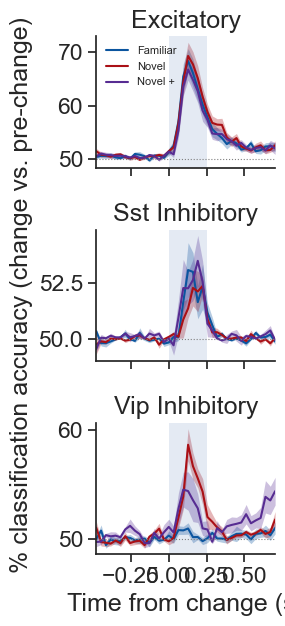

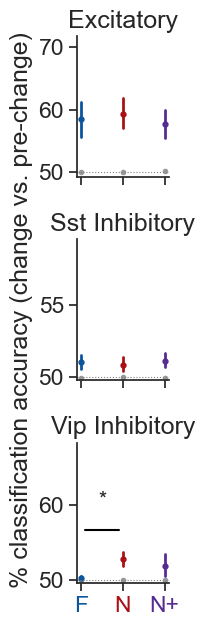

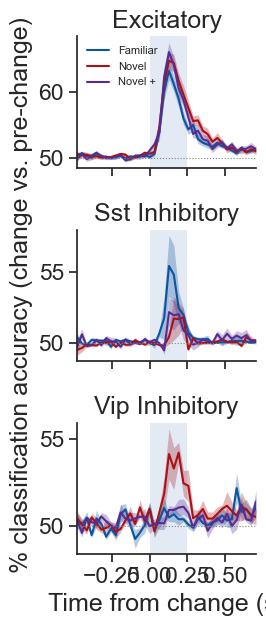

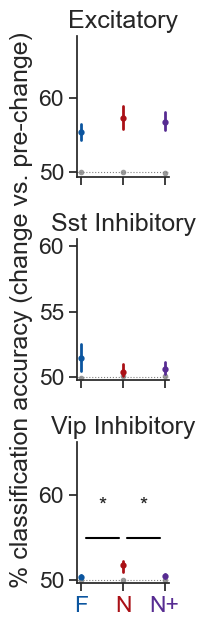

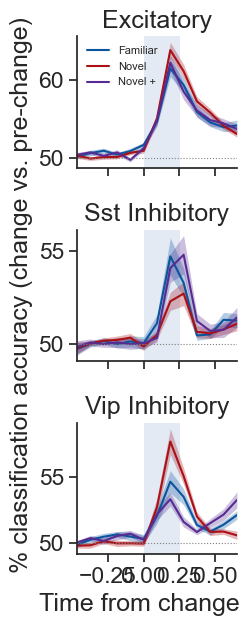

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/909537040.py:26: RuntimeWarning: All-NaN slice encountered
  return a * 100 if np.nanmax(a) <= 1.5 else a   # handle fraction vs percent storage
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:51: RuntimeWarning: Mean of empty slice
  'decoding_accuracy': np.nanmean(to_pct(a)[win]),
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:52: RuntimeWarning: Mean of empty slice
  'shuffle_accuracy':  (np.nanmean(to_pct(sh)[win]) if sh is not None and sh.shape == a.shape else np.nan),


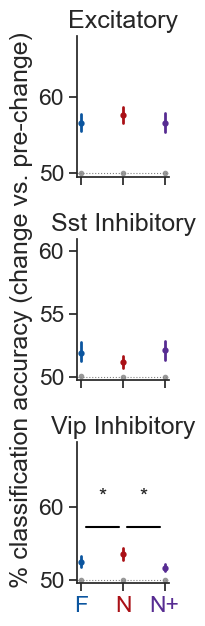

In [93]:
decoding_type = 'decode_changes_from_nochanges'
for project_code in project_codes:
    if project_code not in results[decoding_type]:
        print('[missing] %s / %s' % (decoding_type, project_code)); continue
    _ = show_decoding_figures(results[decoding_type][project_code], project_code, decoding_type)

## 11. decode_next_image_from_omissions -- each project code separately

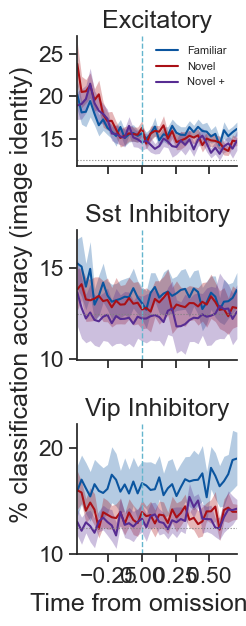

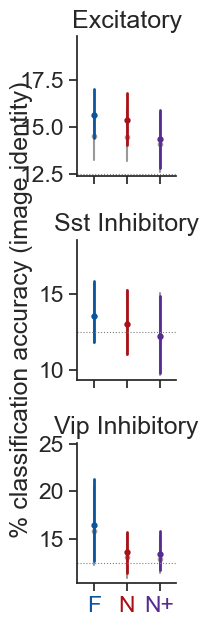

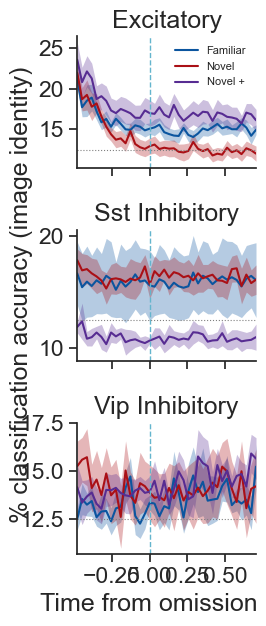

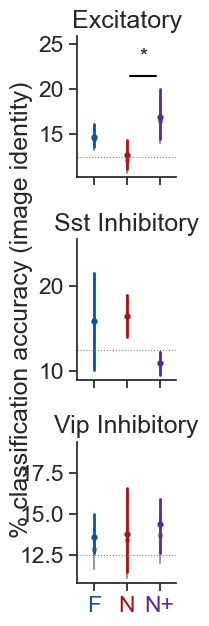

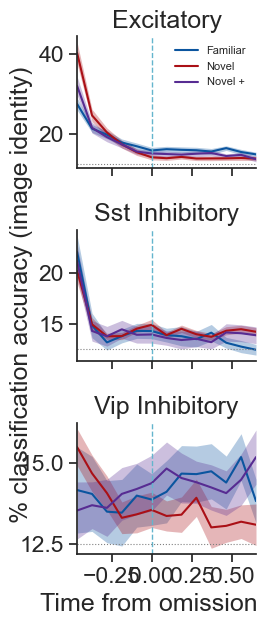

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/909537040.py:26: RuntimeWarning: All-NaN slice encountered
  return a * 100 if np.nanmax(a) <= 1.5 else a   # handle fraction vs percent storage
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:51: RuntimeWarning: Mean of empty slice
  'decoding_accuracy': np.nanmean(to_pct(a)[win]),
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:52: RuntimeWarning: Mean of empty slice
  'shuffle_accuracy':  (np.nanmean(to_pct(sh)[win]) if sh is not None and sh.shape == a.shape else np.nan),


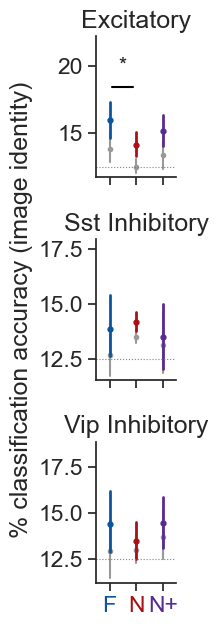

In [94]:
decoding_type = 'decode_next_image_from_omissions'
for project_code in project_codes:
    if project_code not in results[decoding_type]:
        print('[missing] %s / %s' % (decoding_type, project_code)); continue
    _ = show_decoding_figures(results[decoding_type][project_code], project_code, decoding_type)

## 12. decode_baseline_from_nobaseline -- each project code separately

The baseline reference frames (the dip just before 0) are blanked via `EXCLUDE_TIME_SEC` in Section 8.

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:79: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:79: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:79: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 fo

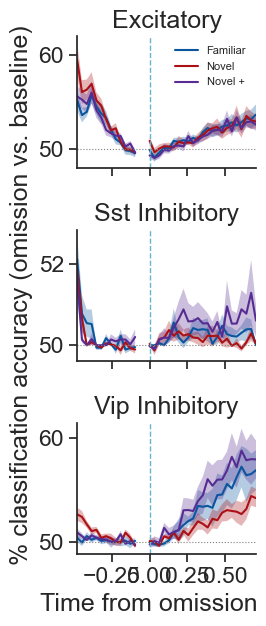

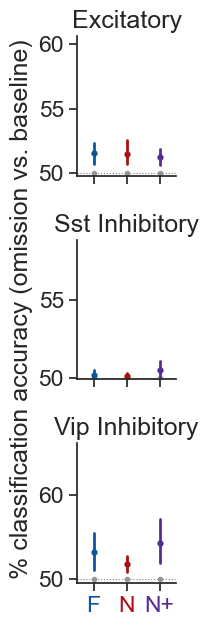

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:79: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:79: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:79: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 fo

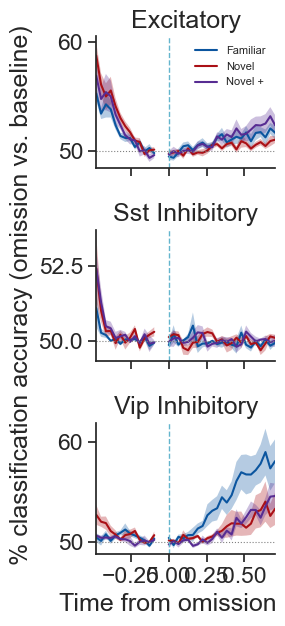

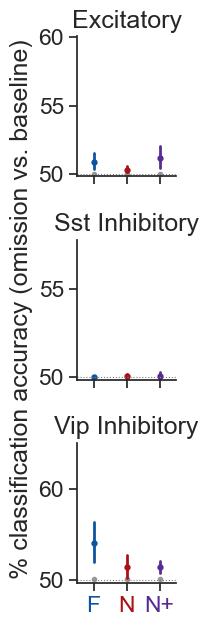

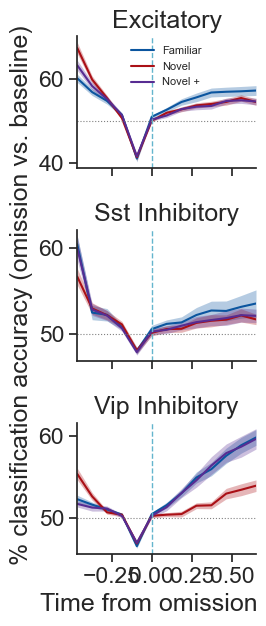

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/909537040.py:26: RuntimeWarning: All-NaN slice encountered
  return a * 100 if np.nanmax(a) <= 1.5 else a   # handle fraction vs percent storage
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:51: RuntimeWarning: Mean of empty slice
  'decoding_accuracy': np.nanmean(to_pct(a)[win]),
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:52: RuntimeWarning: Mean of empty slice
  'shuffle_accuracy':  (np.nanmean(to_pct(sh)[win]) if sh is not None and sh.shape == a.shape else np.nan),


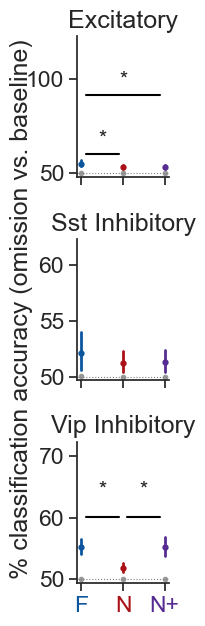

In [95]:
decoding_type = 'decode_baseline_from_nobaseline'
for project_code in project_codes:
    if project_code not in results[decoding_type]:
        print('[missing] %s / %s' % (decoding_type, project_code)); continue
    _ = show_decoding_figures(results[decoding_type][project_code], project_code, decoding_type)

## 13. Aggregate across project codes (resampled to a common onset-relative grid)

Each experiment's trace is interpolated (BOU-style `np.interp`, the same primitive as
`event_triggered_response`) onto a common time grid relative to the aligned event (t=0), defined
over the **overlap** of the project codes' windows at `OUTPUT_SAMPLING_RATE`. Resampling happens
**before** the `EXCLUDE_TIME_SEC` window is blanked, so the baseline gap is applied on the common grid.

In [96]:
def resample_across_projects(decoding_type, project_codes=project_codes,
                             output_sampling_rate=OUTPUT_SAMPLING_RATE,
                             value_cols=(VALUE_COL, SHFL_COL)):
    """Interpolate each experiment's trace onto a common onset-relative grid, pooled across
    project codes. Returns (combined_df, t_common)."""
    natives = {}
    for pc in project_codes:
        d = results.get(decoding_type, {}).get(pc)
        if d is None:
            continue
        iv = input_vars_all.get(decoding_type, {}).get(pc)
        frames_svm = iv['frames_svm'].iloc[0] if iv is not None and 'frames_svm' in iv.columns else None
        natives[pc] = get_time(d, pc, frames_svm=frames_svm)

    # common grid = overlap of native ranges (avoids np.interp extrapolation)
    t_start = max(t.min() for t in natives.values())
    t_end   = min(t.max() for t in natives.values())
    t_common = get_time_array(t_start, t_end, sampling_rate=output_sampling_rate)

    rows = []
    for pc, t_nat in natives.items():
        for _, row in results[decoding_type][pc].iterrows():
            new = {'experiment_id': row['experiment_id'], 'cre': row['cre']}
            ok = True
            for col in value_cols:
                a = np.asarray(row[col], float)
                if a.ndim != 1 or a.shape[0] != t_nat.shape[0]:
                    ok = False
                    break
                new[col] = np.interp(t_common, t_nat, a)   # resample onto common grid
            if ok:
                rows.append(new)
    return pd.DataFrame(rows), t_common

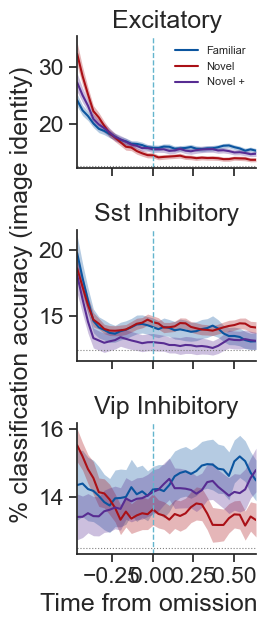

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/909537040.py:26: RuntimeWarning: All-NaN slice encountered
  return a * 100 if np.nanmax(a) <= 1.5 else a   # handle fraction vs percent storage
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:51: RuntimeWarning: Mean of empty slice
  'decoding_accuracy': np.nanmean(to_pct(a)[win]),
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:52: RuntimeWarning: Mean of empty slice
  'shuffle_accuracy':  (np.nanmean(to_pct(sh)[win]) if sh is not None and sh.shape == a.shape else np.nan),


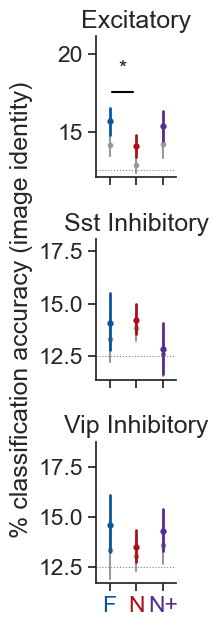

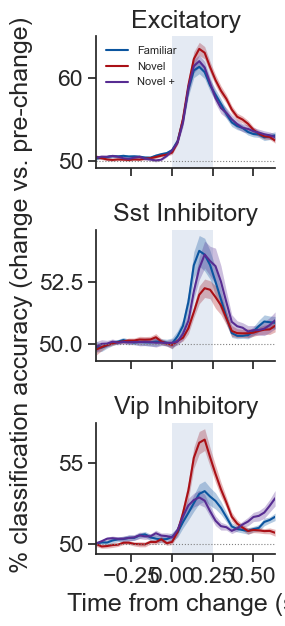

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/909537040.py:26: RuntimeWarning: All-NaN slice encountered
  return a * 100 if np.nanmax(a) <= 1.5 else a   # handle fraction vs percent storage
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:51: RuntimeWarning: Mean of empty slice
  'decoding_accuracy': np.nanmean(to_pct(a)[win]),
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:52: RuntimeWarning: Mean of empty slice
  'shuffle_accuracy':  (np.nanmean(to_pct(sh)[win]) if sh is not None and sh.shape == a.shape else np.nan),


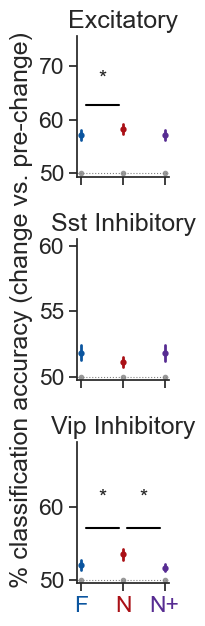

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:79: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:79: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:79: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 fo

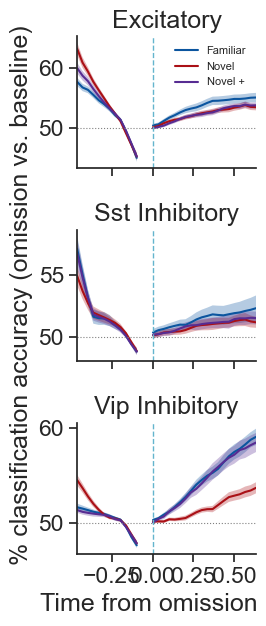

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/909537040.py:26: RuntimeWarning: All-NaN slice encountered
  return a * 100 if np.nanmax(a) <= 1.5 else a   # handle fraction vs percent storage
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:51: RuntimeWarning: Mean of empty slice
  'decoding_accuracy': np.nanmean(to_pct(a)[win]),
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6333/2354814068.py:52: RuntimeWarning: Mean of empty slice
  'shuffle_accuracy':  (np.nanmean(to_pct(sh)[win]) if sh is not None and sh.shape == a.shape else np.nan),


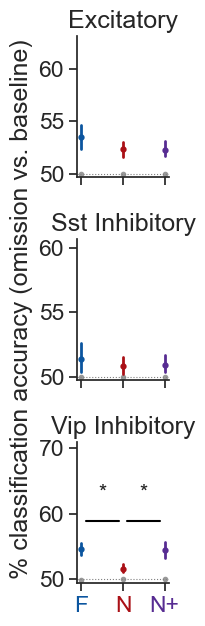

In [97]:
for decoding_type in decoding_types:
    combined, t_common = resample_across_projects(decoding_type)
    _ = show_decoding_figures(combined, 'aggregated (all project codes)', decoding_type,
                              time_override=t_common)